In [1]:
import pandas as pd

full_df = pd.read_csv('/kaggle/input/datasets/zaczinho/epl-results/full.csv')

In [2]:
full_df.head()

,Unnamed: 0,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,AST,HF,AF,HC,AC,HY,AY,HR,AR,Season
0,0,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,4,13,12,6,6,1,2,0,0,1
1,1,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,5,19,14,7,7,1,2,0,0,1
2,2,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,9,15,21,8,4,5,3,1,0,1
3,3,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,6,11,13,5,8,1,1,0,0,1
4,4,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,6,21,20,6,4,1,3,0,0,1


In [3]:
import pandas as pd
import numpy as np

full_df = full_df[full_df['Date'] >= '2000-08-01'].reset_index(drop=True)

# 2. Tạo cột Season dựa trên chỉ số (Index)
# Cứ mỗi 380 dòng sẽ là 1 mùa
full_df['Season_Idx'] = (full_df.index // 380)

# 3. Tạo tên mùa giải trực quan (Ví dụ: Season 0, Season 1...) 
# Hoặc mapping cụ thể nếu bạn muốn
seasons = [
    '0001', '0102', '0203', '0304', '0405', '0506', '0607', '0708', '0809', '0910',
    '1011', '1112', '1213', '1314', '1415', '1516', '1617', '1718', '1819', '1920',
    '2021', '2122', '2223', '2324', '2425'
]

# Gán tên mùa giải thực tế vào dựa trên Season_Idx
full_df['Season_Name'] = full_df['Season_Idx'].apply(
    lambda x: seasons[x] if x < len(seasons) else f"Extra_{x}"
)

print(f"Tổng số mùa giải: {full_df['Season_Idx'].nunique()}")
print(full_df[['Date', 'HomeTeam', 'AwayTeam', 'Season_Name']].head(10))

Tổng số mùa giải: 25
         Date    HomeTeam       AwayTeam Season_Name
0  2000-08-19    Charlton       Man City        0001
1  2000-08-19     Chelsea       West Ham        0001
2  2000-08-19    Coventry  Middlesbrough        0001
3  2000-08-19       Derby    Southampton        0001
4  2000-08-19       Leeds        Everton        0001
5  2000-08-19   Leicester    Aston Villa        0001
6  2000-08-19   Liverpool       Bradford        0001
7  2000-08-19  Sunderland        Arsenal        0001
8  2000-08-19   Tottenham        Ipswich        0001
9  2000-08-20  Man United      Newcastle        0001


In [4]:
full_df.head()

,Unnamed: 0,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,AF,HC,AC,HY,AY,HR,AR,Season,Season_Idx,Season_Name
0,0,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,12,6,6,1,2,0,0,1,0,0001
1,1,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,14,7,7,1,2,0,0,1,0,0001
2,2,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,21,8,4,5,3,1,0,1,0,0001
3,3,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,13,5,8,1,1,0,0,1,0,0001
4,4,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,20,6,4,1,3,0,0,1,0,0001


In [5]:
full_df.isnull().sum()

Unnamed: 0     0
Date           0
HomeTeam       0
AwayTeam       0
FTHG           0
FTAG           0
FTR            0
HTHG           0
HTAG           0
HTR            0
Referee        0
HS             0
AS             0
HST            0
AST            0
HF             0
AF             0
HC             0
AC             0
HY             0
AY             0
HR             0
AR             0
Season         0
Season_Idx     0
Season_Name    0
dtype: int64

# Phân tích phân phối (distribution and missing)

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

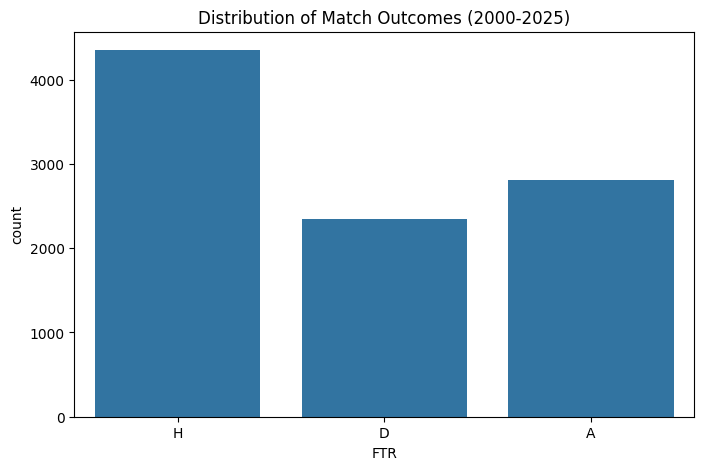

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(x='FTR', data=full_df, order=['H', 'D', 'A']) # FTR - Full time results
plt.title('Distribution of Match Outcomes (2000-2025)')
plt.show()


## Time series EDA

### Tỷ lệ thắng sân nhà

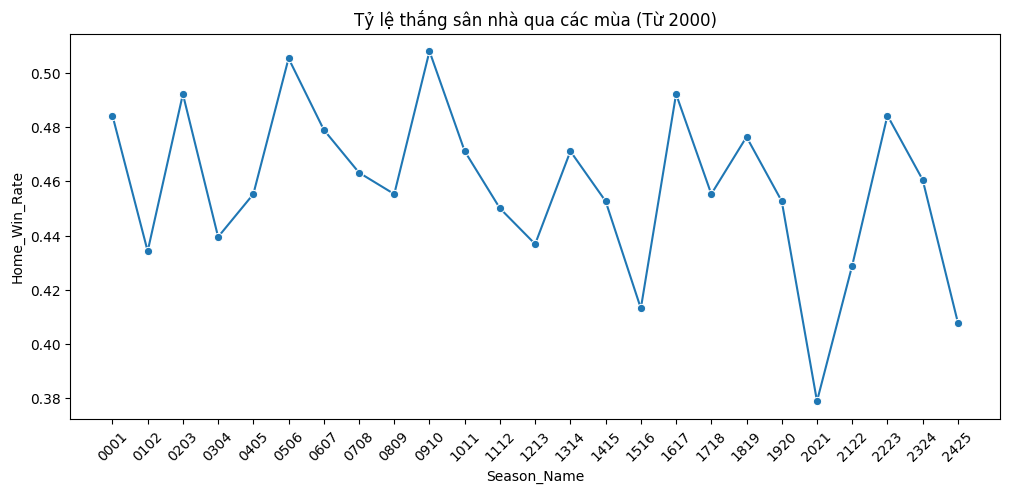

In [8]:
home_win_analysis = full_df.groupby('Season_Name').apply(
    lambda x: (x['FTR'] == 'H').sum() / len(x), include_groups = False
).reset_index(name='Home_Win_Rate')

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.lineplot(data=home_win_analysis, x='Season_Name', y='Home_Win_Rate', marker='o')
plt.title('Tỷ lệ thắng sân nhà qua các mùa (Từ 2000)')
plt.xticks(rotation=45)
plt.show()

tỉ lệ thắng sân nhà vào năm 20-21 giảm mạnh do mất lợi thế sân nhà do không có khán giả

### Số bàn thắng trung bình

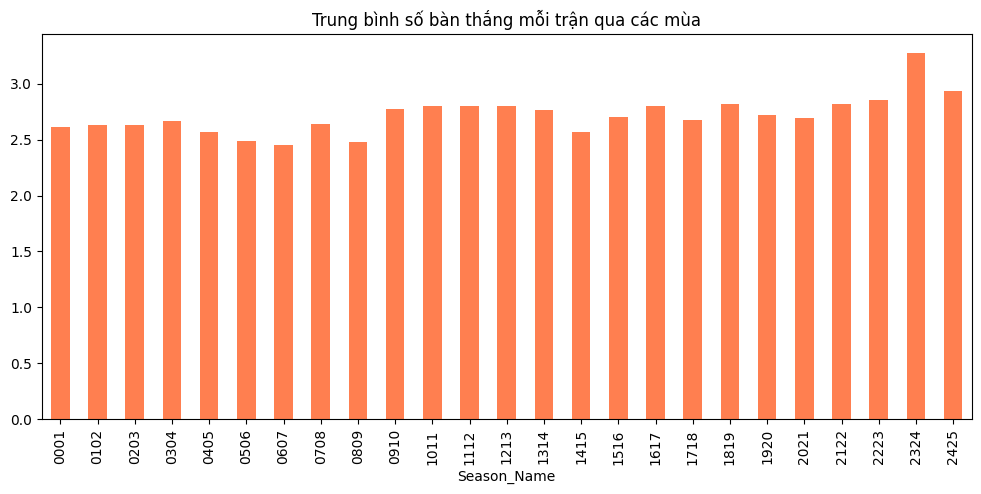

In [9]:
full_df['Total_Goals'] = full_df['FTHG'] + full_df['FTAG']
avg_goals_season = full_df.groupby('Season_Name')['Total_Goals'].mean()

plt.figure(figsize=(12, 5))
avg_goals_season.plot(kind='bar', color='coral')
plt.title('Trung bình số bàn thắng mỗi trận qua các mùa')
plt.show()

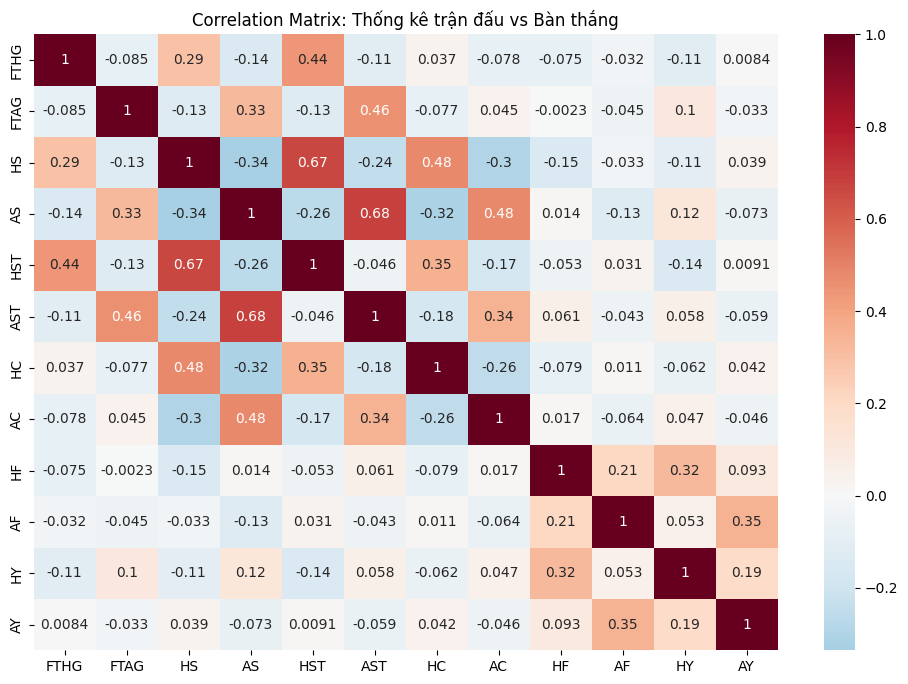

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Chọn các cột số để tính tương quan
cols_corr = ['FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY']
corr_matrix = full_df[cols_corr].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Matrix: Thống kê trận đấu vs Bàn thắng')
plt.show()

HST liên quan mạnh đến HS
AST cũng liên quan mạnh đến AS

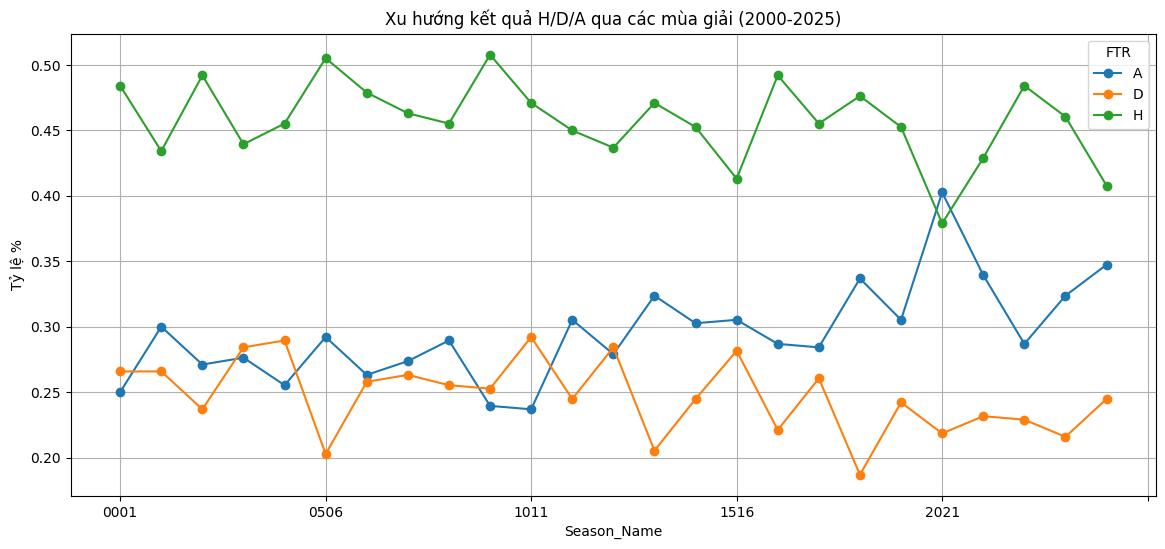

In [11]:
# Tính tỷ lệ % H/D/A theo từng mùa
outcomes_per_season = full_df.groupby('Season_Name')['FTR'].value_counts(normalize=True).unstack()

outcomes_per_season.plot(kind='line', marker='o', figsize=(14, 6))
plt.title('Xu hướng kết quả H/D/A qua các mùa giải (2000-2025)')
plt.ylabel('Tỷ lệ %')
plt.grid(True)
plt.show()

20-21 là mùa giải đột biến khi mà lợi thế sân nhà không còn. Những năm còn lại thì tỷ lệ thắng sân nhà vẫn cao hơn. tỷ lệ hòa và tỷ lệ khách thắng cơ bản là ngang nhau, tuy nhiên away có phần nhỉnh hơn.

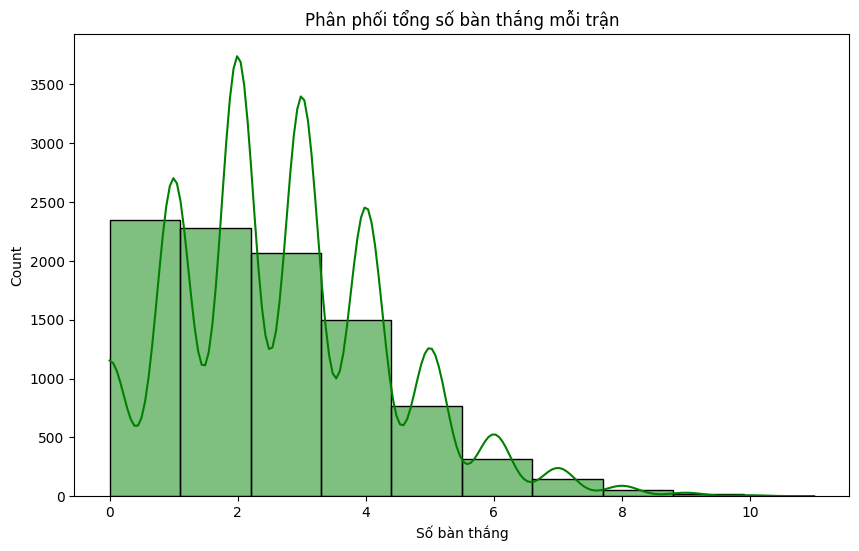

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(full_df['Total_Goals'], bins=10, kde=True, color='green')
plt.title('Phân phối tổng số bàn thắng mỗi trận')
plt.xlabel('Số bàn thắng')
plt.show()

KDE -> xu hướng ít bàn thắng (<4)

Kiểm tra xem số bàn thắng có tuân theo phân phối Poisson không (đây là giả định cơ bản của nhiều mô hình dự đoán bóng đá).

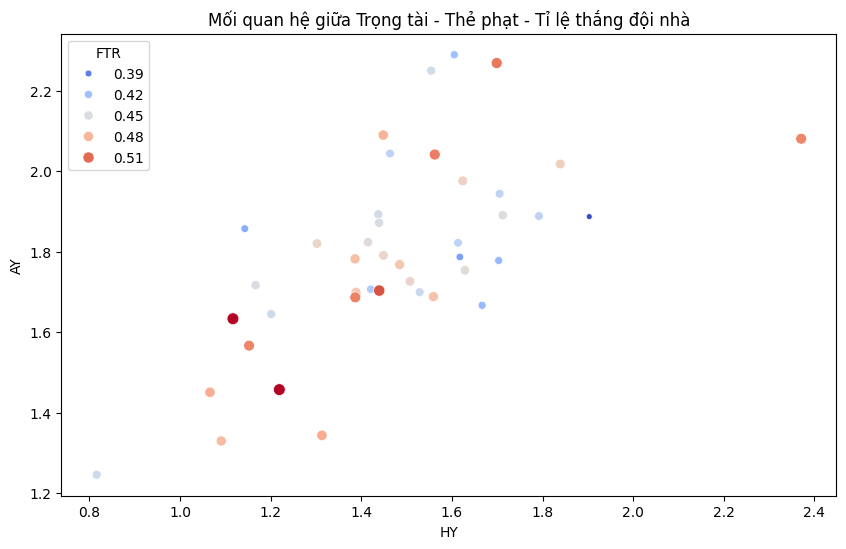

In [13]:
# Lọc các trọng tài bắt trên 50 trận
ref_stats = full_df.groupby('Referee').agg({
    'FTR': lambda x: (x == 'H').mean(), # Tỉ lệ chủ nhà thắng khi trọng tài này bắt
    'HY': 'mean', # Trung bình thẻ vàng đội nhà
    'AY': 'mean'  # Trung bình thẻ vàng đội khách
}).loc[full_df['Referee'].value_counts() > 50]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=ref_stats, x='HY', y='AY', size='FTR', hue='FTR', palette='coolwarm')
plt.title('Mối quan hệ giữa Trọng tài - Thẻ phạt - Tỉ lệ thắng đội nhà')
plt.show()

Có trọng tài bắt nặng tay, có trọng tài thì không, nhìn chung thì thẻ phạt cho away sẽ nhiều hơn

In [14]:
def smart_date_parser(date_str):
    if pd.isna(date_str):
        return pd.NaT
    # Các định dạng phổ biến trong dữ liệu Football-data
    for fmt in ('%d/%m/%y', '%d/%m/%Y', '%Y-%m-%d'):
        try:
            return pd.to_datetime(date_str, format=fmt)
        except (ValueError, TypeError):
            continue
    # Nếu không khớp cái nào, để Pandas tự đoán lần cuối
    return pd.to_datetime(date_str, errors='coerce')

# Áp dụng hàm cho cột Date
full_df['Date'] = full_df['Date'].apply(smart_date_parser)

# Sau đó nhớ sort lại để đảm bảo thứ tự các trận đấu
full_df = full_df.sort_values('Date').reset_index(drop=True)
full_df['Month'] = full_df['Date'].dt.month

In [15]:
import numpy as np

# --- BƯỚC 1: Xử lý Month sang Sin/Cos ---
# Giúp mô hình hiểu tính chu kỳ (Tháng 12 gần Tháng 1)
full_df['Month_Sin'] = np.sin(2 * np.pi * full_df['Month'] / 12)
full_df['Month_Cos'] = np.cos(2 * np.pi * full_df['Month'] / 12)

# --- BƯỚC 2: Tạo cột Season (Cần thiết để reset Matchweek mỗi năm) ---
# Mùa giải Ngoại hạng Anh thường bắt đầu từ tháng 8
full_df['Season'] = full_df['Date'].apply(lambda x: f"{x.year}-{x.year+1}" if x.month >= 8 else f"{x.year-1}-{x.year}")

# --- BƯỚC 3: Tính Matchweek tự động ---
def calculate_matchweek(df):
    df = df.sort_values(['Season', 'Date']).copy()
    
    # Dictionary lưu số trận đã đá của từng đội trong từng mùa
    counts = {} 
    mws = []
    
    for idx, row in df.iterrows():
        s = row['Season']
        h = row['HomeTeam']
        a = row['AwayTeam']
        
        if s not in counts:
            counts[s] = {}
            
        # Lấy số trận hiện tại của 2 đội, mặc định là 0
        h_played = counts[s].get(h, 0)
        a_played = counts[s].get(a, 0)
        
        # Matchweek là số trận lớn nhất của 2 đội + 1 (để xử lý cả trận đá bù)
        current_mw = max(h_played, a_played) + 1
        mws.append(current_mw)
        
        # Cập nhật số trận đã đá cho trận tiếp theo
        counts[s][h] = h_played + 1
        counts[s][a] = a_played + 1
        
    df['Matchweek'] = mws
    return df

full_df = calculate_matchweek(full_df)

# Kiểm tra nhanh kết quả
print(full_df[['Date', 'HomeTeam', 'AwayTeam', 'Month_Sin', 'Matchweek']].tail(10))

           Date       HomeTeam        AwayTeam  Month_Sin  Matchweek
9490 2025-05-25         Fulham        Man City        0.5         38
9491 2025-05-25        Ipswich        West Ham        0.5         38
9492 2025-05-25    Bournemouth       Leicester        0.5         38
9493 2025-05-25      Tottenham        Brighton        0.5         38
9494 2025-05-25      Liverpool  Crystal Palace        0.5         38
9495 2025-05-25    Southampton         Arsenal        0.5         38
9496 2025-05-25      Newcastle         Everton        0.5         38
9497 2025-05-25  Nott'm Forest         Chelsea        0.5         38
9498 2025-05-25     Man United     Aston Villa        0.5         38
9499 2025-05-25         Wolves       Brentford        0.5         38


In [16]:
full_df.head()

,Unnamed: 0,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HR,AR,Season,Season_Idx,Season_Name,Total_Goals,Month,Month_Sin,Month_Cos,Matchweek
0,0,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,0,0,2000-2001,0,0001,4,8,-0.866025,-0.5,1
1,1,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,0,0,2000-2001,0,0001,6,8,-0.866025,-0.5,1
2,2,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,1,0,2000-2001,0,0001,4,8,-0.866025,-0.5,1
3,3,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,0,0,2000-2001,0,0001,4,8,-0.866025,-0.5,1
4,4,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,0,0,2000-2001,0,0001,2,8,-0.866025,-0.5,1


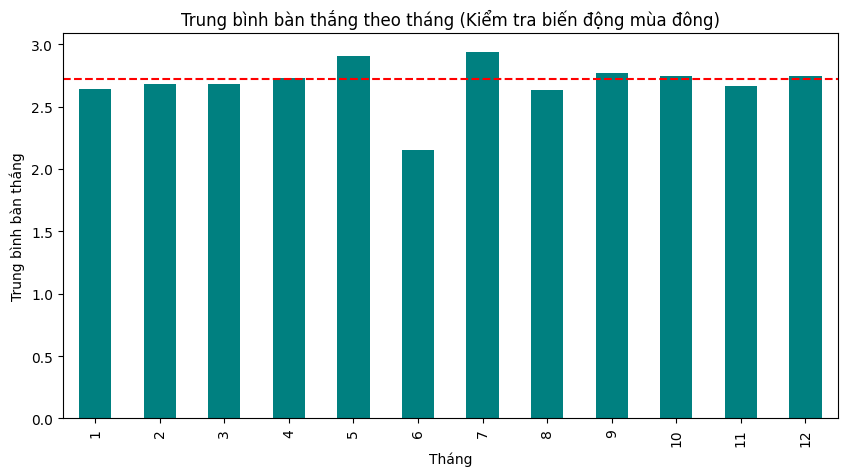

In [17]:
monthly_goals = full_df.groupby('Month')['Total_Goals'].mean()

plt.figure(figsize=(10, 5))
monthly_goals.plot(kind='bar', color='teal')
plt.title('Trung bình bàn thắng theo tháng (Kiểm tra biến động mùa đông)')
plt.axhline(y=full_df['Total_Goals'].mean(), color='r', linestyle='--')
plt.ylabel('Trung bình bàn thắng')
plt.xlabel('Tháng')
plt.show()

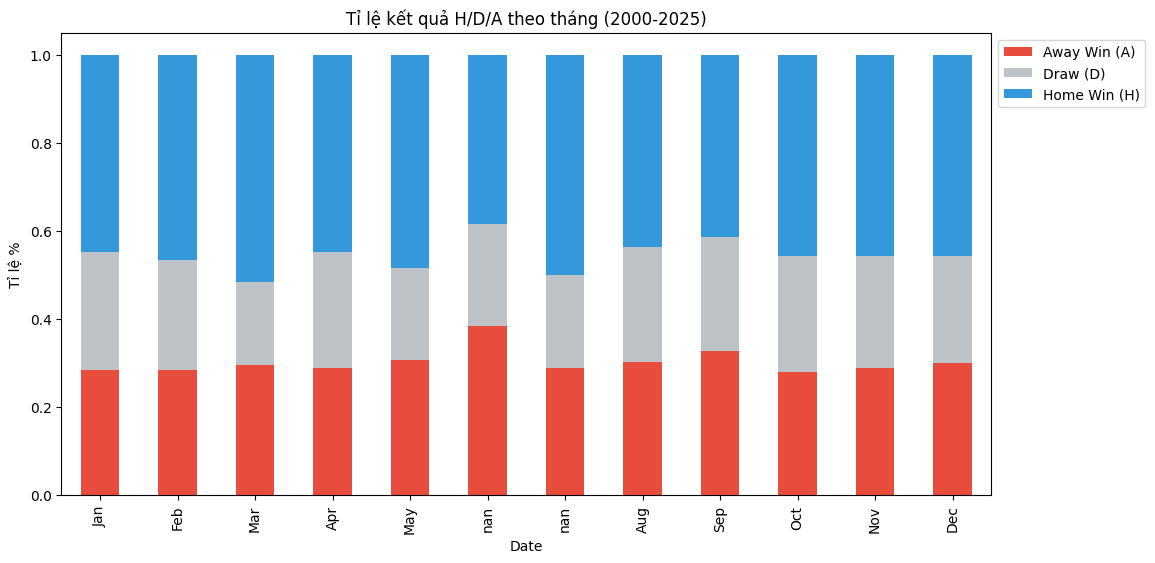

In [18]:
# Tính tỷ lệ thắng (H), hòa (D), thua (A) theo tháng
monthly_results = full_df.groupby(full_df['Date'].dt.month)['FTR'].value_counts(normalize=True).unstack()

# Đổi tên index từ số (1, 2...) sang chữ (Jan, Feb...) để dễ đọc
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
monthly_results.index = monthly_results.index.map(month_names)

# Vẽ biểu đồ chồng (Stacked Bar Chart)
monthly_results.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#e74c3c', '#bdc3c7', '#3498db'])
plt.title('Tỉ lệ kết quả H/D/A theo tháng (2000-2025)')
plt.legend(['Away Win (A)', 'Draw (D)', 'Home Win (H)'], bbox_to_anchor=(1, 1))
plt.ylabel('Tỉ lệ %')
plt.show()

Theo tháng như các tuần lễ quan trọng mà nhiều biến động thì số bàn thắng, sự thay đổi giữa home win và away win hay draw nhìn chung không có gì thay đổi. Ví dụ như tháng 12 có tuần lễ boxing days nổi tiếng căng thẳng và nhiều sự bất ngờ thì cũng không khác các tháng trước là mấy

# FEATURE ENGINEERING

In [19]:
import pandas as pd
import numpy as np

def create_rolling_features(df, n_games=5):
    # Các cột cần tính trung bình
    cols = ['HS', 'AS', 'HST', 'AST', 'FTHG', 'FTAG', 'HC', 'AC']
    
    # Sắp xếp theo ngày để đảm bảo thứ tự thời gian
    df = df.sort_values('Date')
    
    # Tạo các cột rỗng
    new_cols = [f'Home_Avg_HS_{n_games}', f'Home_Avg_HST_{n_games}', 
                f'Away_Avg_HS_{n_games}', f'Away_Avg_HST_{n_games}',
                f'Home_Avg_Goals_Conceded_{n_games}', f'Away_Avg_Goals_Conceded_{n_games}']
    
    for col in new_cols:
        df[col] = np.nan

    # Group theo từng đội để tính phong độ riêng
    all_teams = pd.concat([df['HomeTeam'], df['AwayTeam']]).unique()
    
    for team in all_teams:
        # Lấy tất cả các trận của đội này (cả sân nhà và sân khách)
        team_mask = (df['HomeTeam'] == team) | (df['AwayTeam'] == team)
        team_df = df[team_mask].copy()
        
        # Xác định chỉ số của đội này trong từng trận (Ghi bàn và Bị thủng lưới)
        team_goals = team_df.apply(lambda x: x['FTHG'] if x['HomeTeam'] == team else x['FTAG'], axis=1)
        team_conceded = team_df.apply(lambda x: x['FTAG'] if x['HomeTeam'] == team else x['FTHG'], axis=1)
        team_shots = team_df.apply(lambda x: x['HS'] if x['HomeTeam'] == team else x['AS'], axis=1)
        team_shots_ot = team_df.apply(lambda x: x['HST'] if x['HomeTeam'] == team else x['AST'], axis=1)
        
        # Tính trung bình trượt (dùng shift(1) để không lấy kết quả trận hiện tại)
        roll_goals_conceded = team_conceded.shift(1).rolling(window=n_games).mean()
        roll_shots = team_shots.shift(1).rolling(window=n_games).mean()
        roll_shots_ot = team_shots_ot.shift(1).rolling(window=n_games).mean()
        
        # Cập nhật ngược lại vào dataframe chính
        for idx, row in team_df.iterrows():
            if row['HomeTeam'] == team:
                df.at[idx, f'Home_Avg_HS_{n_games}'] = roll_shots.loc[idx]
                df.at[idx, f'Home_Avg_HST_{n_games}'] = roll_shots_ot.loc[idx]
                df.at[idx, f'Home_Avg_Goals_Conceded_{n_games}'] = roll_goals_conceded.loc[idx]
            else:
                df.at[idx, f'Away_Avg_HS_{n_games}'] = roll_shots.loc[idx]
                df.at[idx, f'Away_Avg_HST_{n_games}'] = roll_shots_ot.loc[idx]
                df.at[idx, f'Away_Avg_Goals_Conceded_{n_games}'] = roll_goals_conceded.loc[idx]
                
    return df

full_df = create_rolling_features(full_df)

In [20]:
full_df.head(100)

,Unnamed: 0,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,Month,Month_Sin,Month_Cos,Matchweek,Home_Avg_HS_5,Home_Avg_HST_5,Away_Avg_HS_5,Away_Avg_HST_5,Home_Avg_Goals_Conceded_5,Away_Avg_Goals_Conceded_5
0,0,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,8,-0.866025,-0.5,1,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,8,-0.866025,-0.5,1,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,8,-0.866025,-0.5,1,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,8,-0.866025,-0.5,1,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,-0.866025,-0.5,1,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,93,2000-10-21,Chelsea,Coventry,6,1,H,2,0,H,...,10,-0.866025,0.5,10,12.2,5.0,6.8,3.2,1.2,1.6
90,96,2000-10-21,Charlton,Middlesbrough,1,0,H,0,0,D,...,10,-0.866025,0.5,10,9.0,5.8,8.0,3.8,1.4,1.6
97,97,2000-10-22,Aston Villa,Sunderland,0,0,D,0,0,D,...,10,-0.866025,0.5,10,10.4,5.2,11.0,5.6,0.8,1.0
98,98,2000-10-23,Southampton,Man City,0,2,A,0,1,A,...,10,-0.866025,0.5,10,10.2,6.0,9.8,6.0,1.0,1.0


In [21]:
# 1. Shot Efficiency (Hiệu quả dứt điểm)
# Lưu ý: Tính trên dữ liệu Rolling đã có để dự đoán trận tới
full_df['Home_Shot_Efficiency'] = full_df['Home_Avg_HST_5'] / full_df['Home_Avg_HS_5']
full_df['Away_Shot_Efficiency'] = full_df['Away_Avg_HST_5'] / full_df['Away_Avg_HS_5']

# 2. Defense Factor (Hệ số phòng ngự)
# Tỉ lệ: Số bàn thua trung bình / Số cú sút trúng đích phải nhận trung bình
# Số càng thấp -> Thủ môn/Hàng thủ càng tốt
full_df['Home_Defense_Ratio'] = full_df['Home_Avg_Goals_Conceded_5'] / (full_df['Home_Avg_HST_5'] + 1e-5)
full_df['Away_Defense_Ratio'] = full_df['Away_Avg_Goals_Conceded_5'] / (full_df['Away_Avg_HST_5'] + 1e-5)

In [22]:
def add_h2h_features(df):
    h2h_map = {} # Lưu trữ cặp đội: [Thắng_Đội_A, Thắng_Đội_B, Hòa]
    
    h2h_home_wins = []
    h2h_away_wins = []
    h2h_draws = []
    
    for idx, row in df.iterrows():
        teams = tuple(sorted([row['HomeTeam'], row['AwayTeam']]))
        team_h = row['HomeTeam']
        team_a = row['AwayTeam']
        
        if teams not in h2h_map:
            h2h_map[teams] = {team_h: 0, team_a: 0, 'draw': 0}
        
        # Lấy dữ liệu trước trận
        current_h2h = h2h_map[teams]
        h2h_home_wins.append(current_h2h.get(team_h, 0))
        h2h_away_wins.append(current_h2h.get(team_a, 0))
        h2h_draws.append(current_h2h['draw'])
        
        # Cập nhật kết quả sau trận
        if row['FTR'] == 'H':
            h2h_map[teams][team_h] += 1
        elif row['FTR'] == 'A':
            h2h_map[teams][team_a] += 1
        else:
            h2h_map[teams]['draw'] += 1
            
    df['Home_H2H_Wins'] = h2h_home_wins
    df['Away_H2H_Wins'] = h2h_away_wins
    df['H2H_Draws'] = h2h_draws
    return df

full_df = add_h2h_features(full_df)

In [23]:
cols_to_drop = [c for c in full_df.columns if 'Unnamed' in c]
full_df = full_df.drop(columns=cols_to_drop)

In [24]:
full_df.head(100)

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,Away_Avg_HST_5,Home_Avg_Goals_Conceded_5,Away_Avg_Goals_Conceded_5,Home_Shot_Efficiency,Away_Shot_Efficiency,Home_Defense_Ratio,Away_Defense_Ratio,Home_H2H_Wins,Away_H2H_Wins,H2H_Draws
0,2000-08-19,Charlton,Man City,4,0,H,2,0,H,Rob Harris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
1,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,Graham Barber,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
2,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,Barry Knight,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
3,2000-08-19,Derby,Southampton,2,2,D,1,2,A,Andy D'Urso,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
4,2000-08-19,Leeds,Everton,2,0,H,2,0,H,Dermot Gallagher,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,2000-10-21,Chelsea,Coventry,6,1,H,2,0,H,Steve Lodge,...,3.2,1.2,1.6,0.409836,0.470588,0.240000,0.499998,0,0,0
90,2000-10-21,Charlton,Middlesbrough,1,0,H,0,0,D,Mike Riley,...,3.8,1.4,1.6,0.644444,0.475000,0.241379,0.421052,0,0,0
97,2000-10-22,Aston Villa,Sunderland,0,0,D,0,0,D,Rob Styles,...,5.6,0.8,1.0,0.500000,0.509091,0.153846,0.178571,0,0,0
98,2000-10-23,Southampton,Man City,0,2,A,0,1,A,Alan Wiley,...,6.0,1.0,1.0,0.588235,0.612245,0.166666,0.166666,0,0,0


In [25]:
# Điền các giá trị NaN bằng giá trị trung bình (Mean Imputation) 
# để không làm mất trận đấu của các đội mới thăng hạng
cols_to_fix = ['Home_Avg_HS_5', 'Home_Avg_HST_5', 'Away_Avg_HS_5', 'Away_Avg_HST_5', 
               'Home_Avg_Goals_Conceded_5', 'Away_Avg_Goals_Conceded_5',
               'Home_Shot_Efficiency', 'Away_Shot_Efficiency', 
               'Home_Defense_Ratio', 'Away_Defense_Ratio']

full_df[cols_to_fix] = full_df[cols_to_fix].fillna(full_df[cols_to_fix].mean())

In [26]:
full_df.head(100)

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,Away_Avg_HST_5,Home_Avg_Goals_Conceded_5,Away_Avg_Goals_Conceded_5,Home_Shot_Efficiency,Away_Shot_Efficiency,Home_Defense_Ratio,Away_Defense_Ratio,Home_H2H_Wins,Away_H2H_Wins,H2H_Draws
0,2000-08-19,Charlton,Man City,4,0,H,2,0,H,Rob Harris,...,5.405756,1.371328,1.337043,0.439693,0.439782,0.308568,0.294306,0,0,0
1,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,Graham Barber,...,5.405756,1.371328,1.337043,0.439693,0.439782,0.308568,0.294306,0,0,0
2,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,Barry Knight,...,5.405756,1.371328,1.337043,0.439693,0.439782,0.308568,0.294306,0,0,0
3,2000-08-19,Derby,Southampton,2,2,D,1,2,A,Andy D'Urso,...,5.405756,1.371328,1.337043,0.439693,0.439782,0.308568,0.294306,0,0,0
4,2000-08-19,Leeds,Everton,2,0,H,2,0,H,Dermot Gallagher,...,5.405756,1.371328,1.337043,0.439693,0.439782,0.308568,0.294306,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,2000-10-21,Chelsea,Coventry,6,1,H,2,0,H,Steve Lodge,...,3.200000,1.200000,1.600000,0.409836,0.470588,0.240000,0.499998,0,0,0
90,2000-10-21,Charlton,Middlesbrough,1,0,H,0,0,D,Mike Riley,...,3.800000,1.400000,1.600000,0.644444,0.475000,0.241379,0.421052,0,0,0
97,2000-10-22,Aston Villa,Sunderland,0,0,D,0,0,D,Rob Styles,...,5.600000,0.800000,1.000000,0.500000,0.509091,0.153846,0.178571,0,0,0
98,2000-10-23,Southampton,Man City,0,2,A,0,1,A,Alan Wiley,...,6.000000,1.000000,1.000000,0.588235,0.612245,0.166666,0.166666,0,0,0


Tạo điểm elo cho mỗi đội, mặc định ban đầu là 1500. chủ nhà có home_advantage = 100. Dựa vào công thức tính được e_h là xác suất thắng của đội chủ nhà. Thắng được 1 điểm, hòa được 0.5 điểm. điểm elo sẽ được cập nhật theo từng trận

In [27]:
import pandas as pd
import numpy as np

def calculate_elo(df, k_factor=30, home_advantage=100):
    # 1. Khởi tạo dictionary lưu điểm ELO hiện tại của các đội
    # Mặc định mỗi đội là 1500
    all_teams = pd.concat([df['HomeTeam'], df['AwayTeam']]).unique()
    elo_ratings = {team: 1500 for team in all_teams}
    
    # Danh sách để lưu ELO TRƯỚC trận đấu (để đưa vào Feature)
    home_elo_before = []
    away_elo_before = []
    
    # Duyệt qua từng trận đấu theo thứ tự thời gian
    for idx, row in df.iterrows():
        home_team = row['HomeTeam']
        away_team = row['AwayTeam']
        result = row['FTR']
        
        # Lấy điểm ELO hiện tại
        r_h = elo_ratings[home_team]
        r_a = elo_ratings[away_team]
        
        # Lưu lại điểm TRƯỚC trận để làm Feature dự đoán
        home_elo_before.append(r_h)
        away_elo_before.append(r_a)
        
        # 2. Tính toán xác suất mong đợi (Expected Score)
        # Có tính đến lợi thế sân nhà (home_advantage)
        e_h = 1 / (1 + 10 ** ((r_a - (r_h + home_advantage)) / 400))
        e_a = 1 - e_h
        
        # 3. Xác định kết quả thực tế (Actual Score)
        if result == 'H':
            s_h, s_a = 1, 0
        elif result == 'A':
            s_h, s_a = 0, 1
        else: # Hòa
            s_h, s_a = 0.5, 0.5
            
        # 4. Cập nhật điểm ELO sau trận đấu
        elo_ratings[home_team] = r_h + k_factor * (s_h - e_h)
        elo_ratings[away_team] = r_a + k_factor * (s_a - e_a)
        
    # Thêm vào dataframe chính
    df['Home_Elo'] = home_elo_before
    df['Away_Elo'] = away_elo_before
    df['Elo_Diff'] = df['Home_Elo'] - df['Away_Elo']
    
    return df, elo_ratings

# Chạy hàm
full_df, final_elo = calculate_elo(full_df)

# Kiểm tra thử Top 5 đội có ELO cao nhất hiện tại (cuối dữ liệu)
print("Top đội mạnh nhất dựa trên ELO:")
sorted_elo = sorted(final_elo.items(), key=lambda x: x[1], reverse=True)
print(sorted_elo[:5])

Top đội mạnh nhất dựa trên ELO:
[('Liverpool', 1804.698383274199), ('Man City', 1795.7140099110354), ('Arsenal', 1791.5266022462483), ('Chelsea', 1719.4508096484449), ('Aston Villa', 1709.2042576636727)]


In [28]:
full_df

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,Home_Shot_Efficiency,Away_Shot_Efficiency,Home_Defense_Ratio,Away_Defense_Ratio,Home_H2H_Wins,Away_H2H_Wins,H2H_Draws,Home_Elo,Away_Elo,Elo_Diff
0,2000-08-19,Charlton,Man City,4,0,H,2,0,H,Rob Harris,...,0.439693,0.439782,0.308568,0.294306,0,0,0,1500.000000,1500.000000,0.000000
1,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,Graham Barber,...,0.439693,0.439782,0.308568,0.294306,0,0,0,1500.000000,1500.000000,0.000000
2,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,Barry Knight,...,0.439693,0.439782,0.308568,0.294306,0,0,0,1500.000000,1500.000000,0.000000
3,2000-08-19,Derby,Southampton,2,2,D,1,2,A,Andy D'Urso,...,0.439693,0.439782,0.308568,0.294306,0,0,0,1500.000000,1500.000000,0.000000
4,2000-08-19,Leeds,Everton,2,0,H,2,0,H,Dermot Gallagher,...,0.439693,0.439782,0.308568,0.294306,0,0,0,1500.000000,1500.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9492,2025-05-25,Bournemouth,Leicester,2,0,H,0,0,D,L Smith,...,0.260000,0.326087,0.461537,0.399999,5,3,5,1604.271696,1425.110731,179.160965
9491,2025-05-25,Ipswich,West Ham,1,3,A,0,1,A,T Robinson,...,0.215686,0.316667,1.090904,0.368420,1,3,1,1403.758402,1529.507711,-125.749309
9490,2025-05-25,Fulham,Man City,0,2,A,0,1,A,A Madley,...,0.285714,0.342466,0.409090,0.080000,4,20,9,1610.550435,1783.831721,-173.281286
9493,2025-05-25,Tottenham,Brighton,1,4,A,1,0,H,R Jones,...,0.270833,0.430769,0.923073,0.321428,9,5,1,1515.256390,1652.542395,-137.286005


In [29]:
full_df.to_csv('/kaggle/working/epl_results.csv', index=False)